In [23]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import KFold
import pickle
from scipy import stats

from notebooks.imports import *
from config import dir_config, main_config
from src.utils import pmf_utils, glm_hmm_utils
from src.utils.glm_hmm_utils_cv import cross_validation_split


In [25]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir = Path(processed_dir, "glm_hmm_models")

glm_hmm_model_name = "with_bias_no_color_1_back_prev_choice_coherence"
max_n_state = 5

In [26]:
with open(Path(glm_hmm_dir, f"{glm_hmm_model_name}.pkl"), "rb") as f:
	glm_hmm = pickle.load(f)

off_meds_glm_hmm = glm_hmm["off_meds"]
on_meds_glm_hmm = glm_hmm["on_meds"]
glm_hmm_config = glm_hmm["config"]

### Model Selection

#### Log-likelihood

In [27]:
# create temp dict glm_hmm without config key
temp_glm_hmm = {}
for key, model in glm_hmm.items():
    if key != "config":
        temp_glm_hmm[key] = model

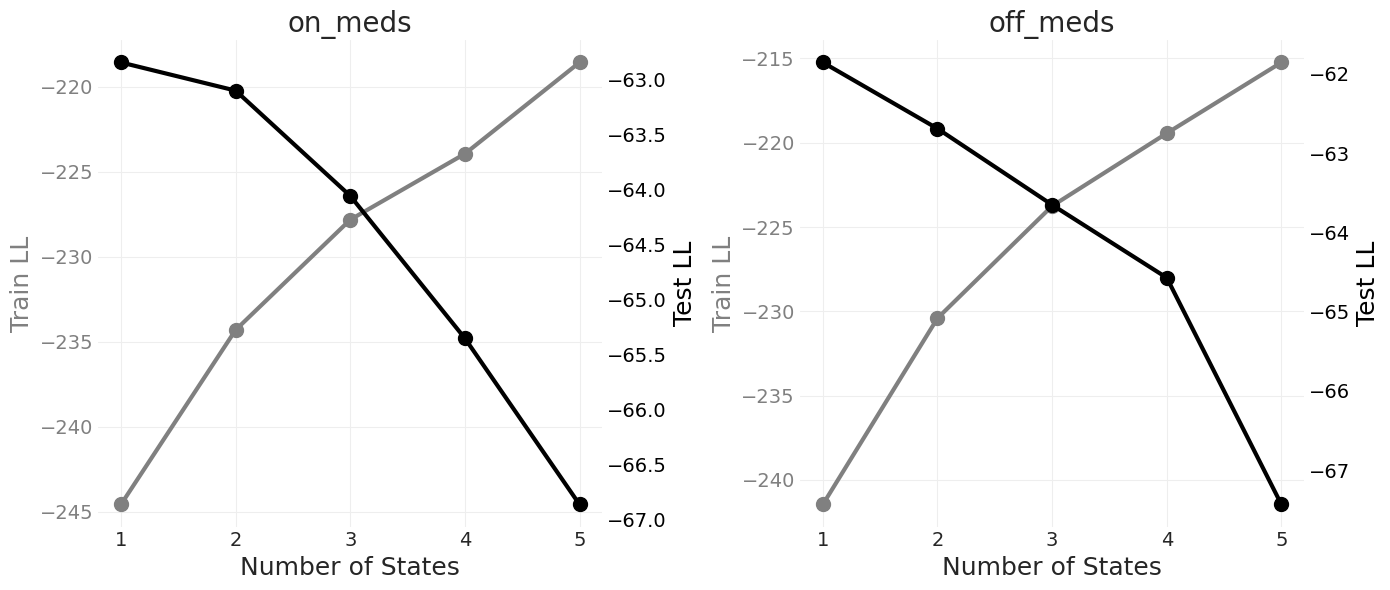

In [28]:
fig, axes = plt.subplots(1, len(temp_glm_hmm.keys()), figsize=(14, 6))

for ax, (key, model) in zip(axes, temp_glm_hmm.items()):
    train_ll = np.mean(model["session_wise"]["train_ll"], axis=(0, 2))
    test_ll = np.mean(model["session_wise"]["test_ll"], axis=(0, 2))
    x = np.arange(1, max_n_state + 1)

    # Train LL
    ax.plot(x, train_ll, marker="o", markersize=10, linewidth=3, color="grey", label="Train LL")
    ax.set_xlabel("Number of States", fontsize=18)
    ax.set_ylabel("Train LL", fontsize=18, color="grey")
    ax.tick_params(axis="y", labelcolor="grey", labelsize=14)
    ax.tick_params(axis="x", labelsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title(key, fontsize=20)

    # Test LL (second axis)
    ax2 = ax.twinx()
    ax2.plot(x, test_ll, marker="o", markersize=10, linewidth=3, color="k", label="Test LL")
    ax2.set_ylabel("Test LL", fontsize=18, color="k")
    ax2.tick_params(axis="y", labelcolor="k", labelsize=14)

    plt.grid(False)

plt.tight_layout()
plt.show()

In [29]:
# for model in [off_meds_glm_hmm, on_meds_glm_hmm]:

for key, model in glm_hmm.items():
    if key in ["config"]:
        continue

    best_state = np.argmax(np.mean(model["session_wise"]["test_ll"], axis=(0, 2))) + 1
    print(f"Best number of states: {best_state}")
    model["best_state"] = 3#best_state
    model["best_state_idx"] = best_state - 1

with open(Path(glm_hmm_dir, f"{glm_hmm_model_name}.pkl"), "wb") as f:
    pickle.dump(glm_hmm, f)


Best number of states: 1
Best number of states: 1


In [30]:
glm_hmm.keys()

dict_keys(['config', 'on_meds', 'off_meds'])

#### Predictive Accuracy

In [31]:
max_n_state = 5
k_folds = 5
def predictive_accuracy(model, choices, input, mask):
    weights = -model.observations.params
    posterior_probs, weighted_sum = [], []
    for idx in range(len(choices)):
        posterior_probs.append(model.expected_states(data=choices[idx], input=input[idx], mask=np.array(mask[idx]).reshape(-1, 1))[0])
        weighted_sum.append(np.sum(weights * input[idx][None, :, :], axis=-1).T)
    sigmoid_output = 1 / (1 + np.exp(-np.concatenate(weighted_sum)))
    glm_hmm_expected_choice_prob = np.sum(sigmoid_output * np.concatenate(posterior_probs), axis=1, keepdims=True)

    log_diff, correct_prediction = [], []
    for prob, choice in zip(glm_hmm_expected_choice_prob, np.concatenate(choices)):
        prob = np.clip(prob, 1e-6, 1 - 1e-6)  # Avoid log(0)
        if ~np.isnan(prob):
            # log_diff.append(np.log(prob) - np.log(0.5))
            if choice == 1:
                correct_prediction.append(prob > 0.5)
                log_diff.append(np.log(prob) - np.log(0.5))
            elif choice == 0:
                correct_prediction.append(prob < 0.5)
                log_diff.append(np.log(1 - prob) - np.log(0.5))
    return np.mean(correct_prediction), log_diff, correct_prediction


In [32]:
# -------------------------
# Function to compute predictive accuracies for a dataset (off_meds or on_meds)
# -------------------------
def compute_pred_accuracies(glm_hmm, session_ids, max_n_state, k_folds):
    # Arrays to store accuracies
    train_pred_accuracies = np.full((len(session_ids), max_n_state, k_folds), np.nan)
    test_pred_accuracies = np.full((len(session_ids), max_n_state, k_folds), np.nan)

    # Logs and correlations (optional, if you want to store them)
    test_pred_log = {idx_session: {state: [] for state in range(1, max_n_state + 1)} for idx_session in range(len(session_ids))}
    train_pred_log = {idx_session: {state: [] for state in range(1, max_n_state + 1)} for idx_session in range(len(session_ids))}
    test_pred_corr = {idx_session: {state: [] for state in range(1, max_n_state + 1)} for idx_session in range(len(session_ids))}
    train_pred_corr = {idx_session: {state: [] for state in range(1, max_n_state + 1)} for idx_session in range(len(session_ids))}

    # Loop through states, sessions, and folds
    for state in range(1, max_n_state + 1):
        for idx_session, session in enumerate(session_ids):
            # df = glm_hmm["data"][session]
            # n_trial_back = detect_n_trial_back(df)
            for fold in range(k_folds):
                model = glm_hmm["session_wise"]["models"][idx_session][state][fold]
                choices = glm_hmm["data"][session]["choices"].values.reshape(-1, 1)
                train_idx, test_idx = cross_validation_split(len(choices), idx_split=fold)

                input = np.array(glm_hmm["data"][session][glm_hmm_config["model_features"]])

                # Mask handling
                mask = glm_hmm["data"][session]["mask"]
                mask = np.ones_like(choices, dtype=bool) if mask is None else mask

                # Test data
                test_choices = [choices[test] for test in test_idx]
                test_input = [input[test] for test in test_idx]
                test_mask = [mask[test] for test in test_idx]

                test_acc, log_diff_test, corr_pred_test = predictive_accuracy(model, test_choices, test_input, test_mask)
                test_pred_accuracies[idx_session, state - 1, fold] = test_acc
                test_pred_log[idx_session][state].append(log_diff_test)
                test_pred_corr[idx_session][state].append(corr_pred_test)

                # Train data
                train_choices = [choices[train] for train in train_idx]
                train_input = [input[train] for train in train_idx]
                train_mask = [mask[train] for train in train_idx]

                train_acc, log_diff_train, corr_pred_train = predictive_accuracy(model, train_choices, train_input, train_mask)
                train_pred_accuracies[idx_session, state - 1, fold] = train_acc
                train_pred_log[idx_session][state].append(log_diff_train)
                train_pred_corr[idx_session][state].append(corr_pred_train)

    # Compute means and SEM
    train_foldmean = np.nanmean(train_pred_accuracies, axis=2)
    train_mean = np.mean(train_foldmean, axis=0)
    train_sem = stats.sem(train_foldmean, axis=0)

    test_foldmean = np.nanmean(test_pred_accuracies, axis=2)
    test_mean = np.mean(test_foldmean, axis=0)
    test_sem = stats.sem(test_foldmean, axis=0)

    return train_mean, train_sem, test_mean, test_sem


In [33]:
# -------------------------
# Compute for OFF and ON meds
# -------------------------
max_n_state = 5  # Adjust as needed
k_folds = 5  # Adjust as needed

off_session_ids = list(off_meds_glm_hmm["data"].keys())
on_session_ids = list(on_meds_glm_hmm["data"].keys())

# Compute predictive accuracies
off_train_mean, off_train_sem, off_test_mean, off_test_sem = compute_pred_accuracies(off_meds_glm_hmm, off_session_ids, max_n_state, k_folds)
on_train_mean, on_train_sem, on_test_mean, on_test_sem = compute_pred_accuracies(on_meds_glm_hmm, on_session_ids, max_n_state, k_folds)


# -------------------------
# Plot 1x2 subplots
# -------------------------
x = np.arange(max_n_state) + 1
fig, axs = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# ---- OFF MEDS ----
axs[0].plot(x, off_train_mean, marker="o", markersize=15, linewidth=3, color="gray", label="Train set")
axs[0].errorbar(x, off_train_mean, yerr=off_train_sem, fmt="none", color="gray", alpha=1, capsize=5)

axs[0].plot(x, off_test_mean, marker="o", markersize=15, linewidth=3, color="k", label="Test set")
axs[0].errorbar(x, off_test_mean, yerr=off_test_sem, fmt="none", color="k", alpha=1, capsize=5)

axs[0].set_title("Off Meds", fontsize=23)
axs[0].set_xlabel("Number of States", fontsize=23)
axs[0].set_ylabel("Predictive Accuracy", fontsize=23)
axs[0].set_xticks(x)
axs[0].tick_params(axis="both", which="major", labelsize=18)
axs[0].spines["top"].set_visible(False)
axs[0].spines["right"].set_visible(False)
axs[0].legend(fontsize=15)

# ---- ON MEDS ----
axs[1].plot(x, on_train_mean, marker="o", markersize=15, linewidth=3, color="gray", label="Train set")
axs[1].errorbar(x, on_train_mean, yerr=on_train_sem, fmt="none", color="gray", alpha=1, capsize=5)

axs[1].plot(x, on_test_mean, marker="o", markersize=15, linewidth=3, color="k", label="Test set")
axs[1].errorbar(x, on_test_mean, yerr=on_test_sem, fmt="none", color="k", alpha=1, capsize=5)

axs[1].set_title("On Meds", fontsize=23)
axs[1].set_xlabel("Number of States", fontsize=23)
axs[1].set_xticks(x)
axs[1].tick_params(axis="both", which="major", labelsize=18)
axs[1].spines["top"].set_visible(False)
axs[1].spines["right"].set_visible(False)
axs[1].legend(fontsize=15)

plt.tight_layout()
plt.show()


KeyboardInterrupt: 